# Практическое задание: Линейная регрессия и EDA

## Цель задания
В этом практическом задании вам предстоит выполнить полный анализ данных страховой компании, включая:
1. Разведочный анализ данных (EDA)
2. Визуализацию данных
3. Построение и оценку модели линейной регрессии

## Описание данных
Набор данных содержит информацию о страховых взносах и различных характеристиках клиентов:
- age: возраст
- sex: пол
- bmi: индекс массы тела
- children: количество детей
- smoker: статус курильщика
- region: регион проживания
- charges: страховые выплаты (целевая переменная)

## Задачи
1. Загрузка и первичный анализ данных
2. Очистка и предобработка данных
3. Разведочный анализ данных (EDA)
4. Статистический анализ
5. Подготовка признаков
6. Построение модели линейной регрессии
7. Оценка модели
8. Визуализация результатов

## Задание 1: Загрузка и первичный анализ данных

1. Загрузите библиотеки:
   - pandas для работы с данными
   - numpy для математических операций
   - matplotlib и seaborn для визуализации
   - scipy.stats для статистических тестов

2. Загрузите датасет 'insurance.csv'

3. Выполните первичный анализ данных:
   - Проверьте размерность данных
   - Выведите первые 5 строк
   - Проверьте типы данных
   - Проверьте наличие пропущенных значений
   - Выведите основные статистические характеристики

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

df = pd.read_csv('insurance.csv')
print("Размерность: ", df.shape)

print("5 строк: ")
print(df.head())

print("Типы данных: ")
print(df.dtypes)

print("Пропущенные знач: ")
print(df.isnull().sum())

print("\n Основные хар-ки: ")
print(df.describe())


Размерность:  (1338, 7)
5 строк: 
   age     sex     bmi  children smoker     region      charges
0   19  female  27.900         0    yes  southwest  16884.92400
1   18    male  33.770         1     no  southeast   1725.55230
2   28    male  33.000         3     no  southeast   4449.46200
3   33    male  22.705         0     no  northwest  21984.47061
4   32    male  28.880         0     no  northwest   3866.85520
Типы данных: 
age           int64
sex          object
bmi         float64
children      int64
smoker       object
region       object
charges     float64
dtype: object
Пропущенные знач: 
age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

 Основные хар-ки: 
               age          bmi     children       charges
count  1338.000000  1338.000000  1338.000000   1338.000000
mean     39.207025    30.663397     1.094918  13270.422265
std      14.049960     6.098187     1.205493  12110.011237
min      18.000000    15.960

## Задание 2: Очистка и предобработка данных

1. Проверьте данные на наличие выбросов:
   - Используйте boxplot для числовых переменных
   - Определите наличие выбросов с помощью IQR
   - Примите решение о методе обработки выбросов

2. Проверьте распределение категориальных переменных:
   - Подсчитайте количество уникальных значений
   - Постройте графики распределения

3. Проведите необходимую предобработку:
   - Обработайте выбросы (если необходимо)
   - Преобразуйте категориальные переменные
   - Сохраните предобработанные данные

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB
None


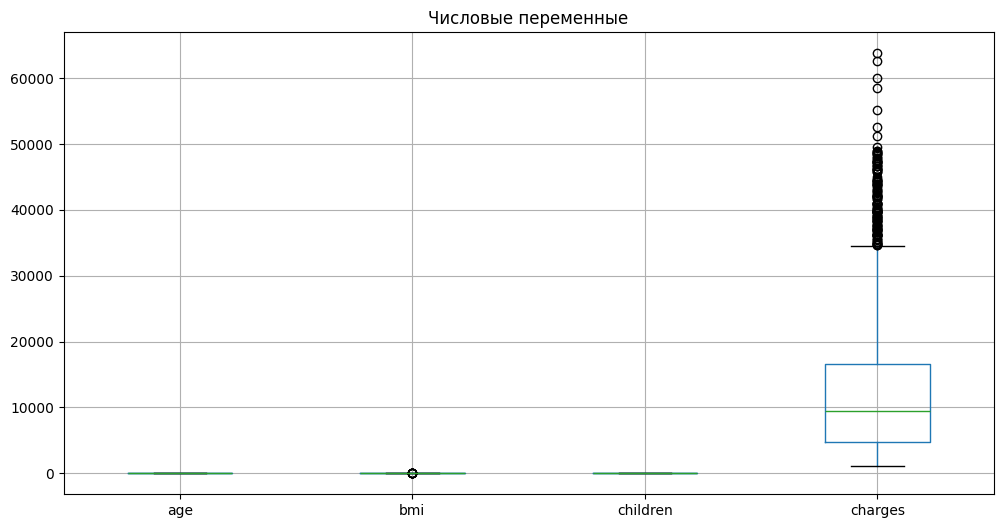

age: выбросов = 0
bmi: выбросов = 9
children: выбросов = 0
charges: выбросов = 139

sex:
sex
male      676
female    662
Name: count, dtype: int64


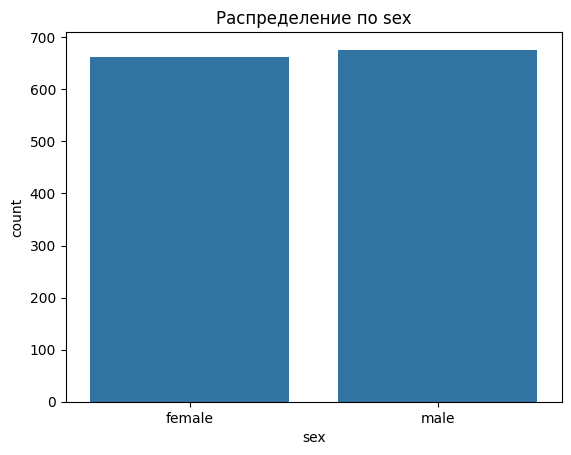


smoker:
smoker
no     1064
yes     274
Name: count, dtype: int64


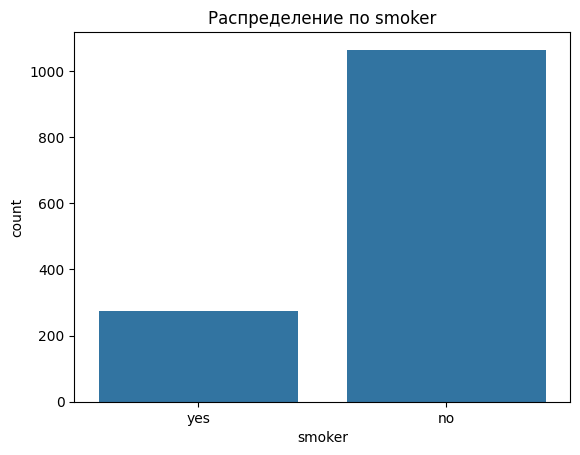


region:
region
southeast    364
southwest    325
northwest    325
northeast    324
Name: count, dtype: int64


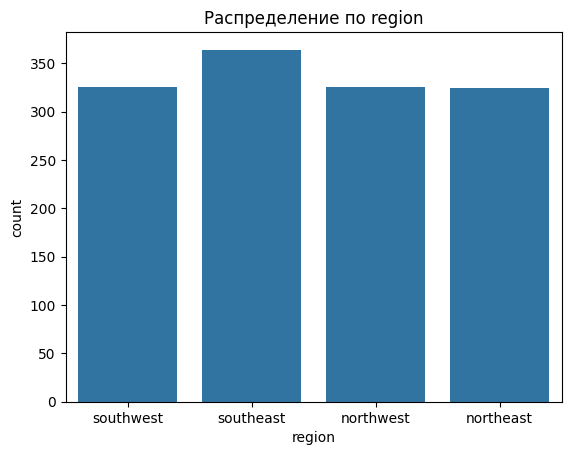

   age     bmi  children      charges  sex_male  smoker_yes  region_northwest  \
0   19  27.900         0  16884.92400     False        True             False   
1   18  33.770         1   1725.55230      True       False             False   
2   28  33.000         3   4449.46200      True       False             False   
3   33  22.705         0  21984.47061      True       False              True   
4   32  28.880         0   3866.85520      True       False              True   

   region_southeast  region_southwest  
0             False              True  
1              True             False  
2              True             False  
3             False             False  
4             False             False  


In [3]:
print(df.info())
nums = ['age', 'bmi', 'children', 'charges']

plt.figure(figsize=(12, 6))
df[nums].boxplot()

plt.title('Числовые переменные')
plt.show()

for col in nums:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower) | (df[col]> upper)]
    print(f"{col}: выбросов = {outliers.shape[0]}")

kat_cols = ['sex', 'smoker', 'region']

for col in kat_cols:
    print(f"\n{col}:")
    print(df[col].value_counts())

    sns.countplot(data=df, x=col)
    plt.title(f"Распределение по {col}")
    plt.show()

df_encoded = pd.get_dummies(df, drop_first=True)
print(df_encoded.head())


## Задание 3: Разведочный анализ данных (EDA)

1. Выполните анализ распределений:
   - Постройте гистограммы для числовых переменных
   - Проверьте нормальность распределений с помощью QQ-plots
   - Визуализируйте распределения с помощью KDE plots

2. Исследуйте взаимосвязи между переменными:
   - Постройте корреляционную матрицу
   - Создайте scatter plots для пар числовых переменных
   - Проанализируйте взаимосвязи с помощью box plots для категориальных переменных

3. Проведите анализ целевой переменной (charges):
   - Исследуйте её распределение
   - Проанализируйте зависимости с другими переменными
   - Проверьте наличие нелинейных связей

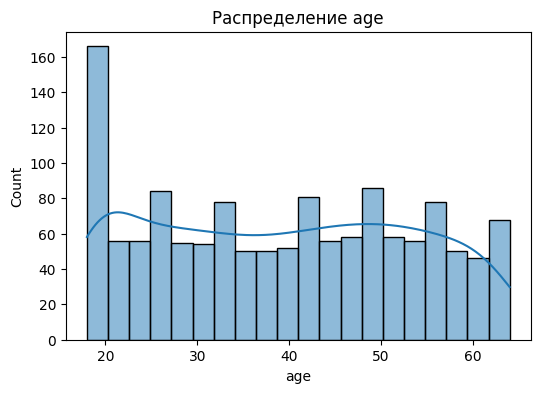

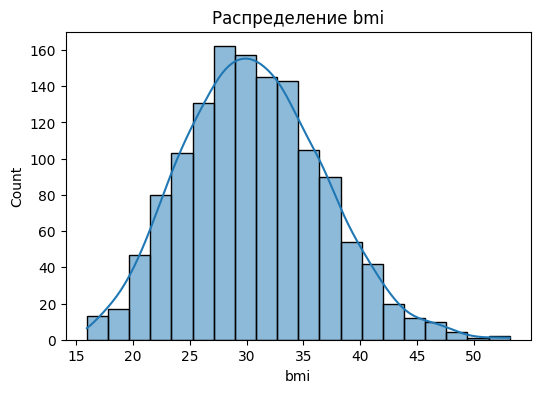

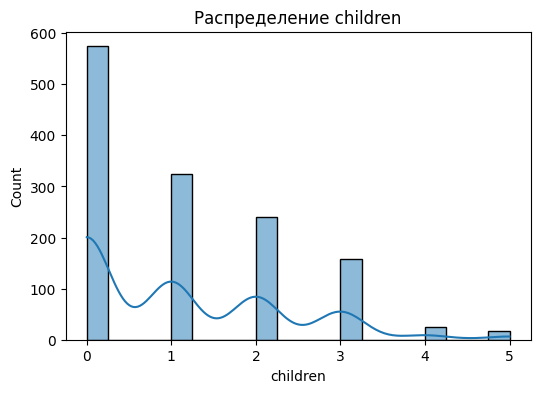

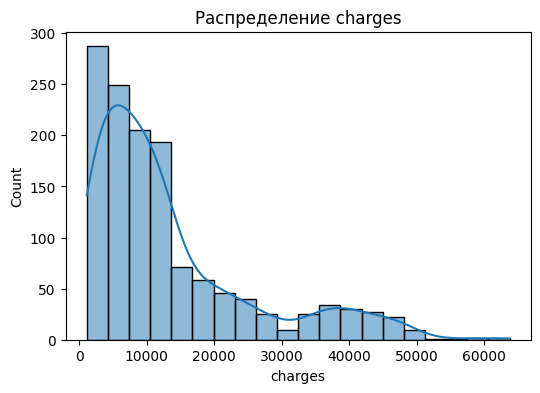

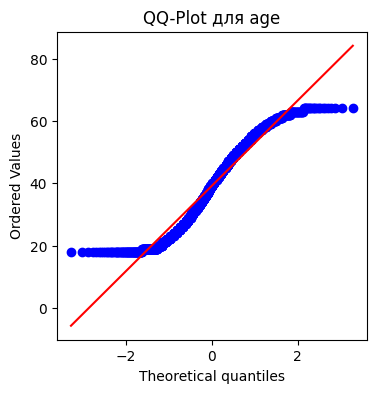

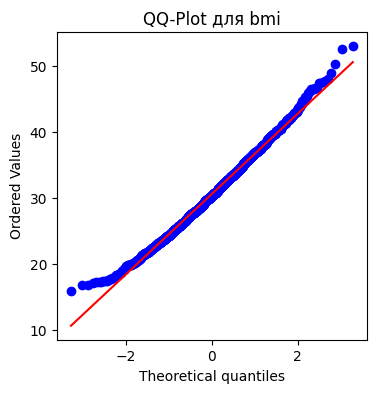

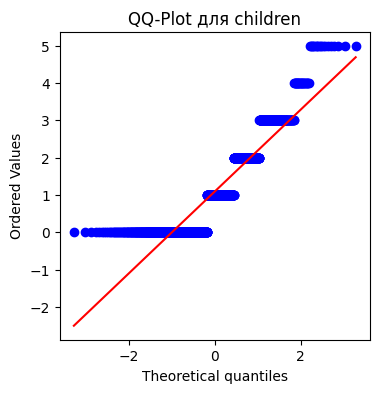

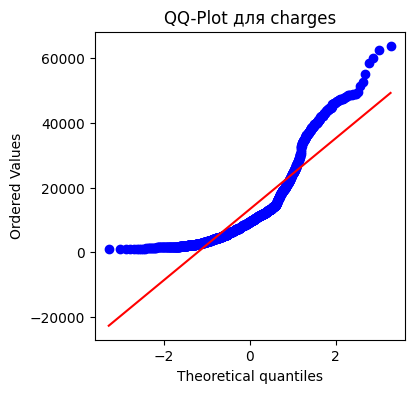

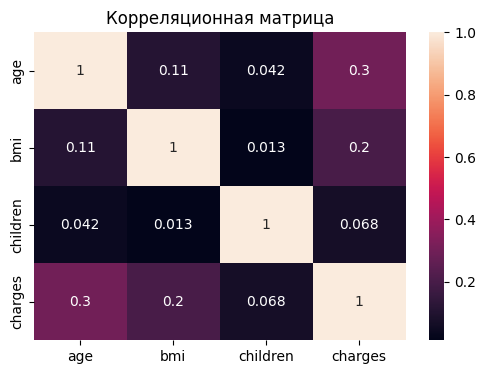

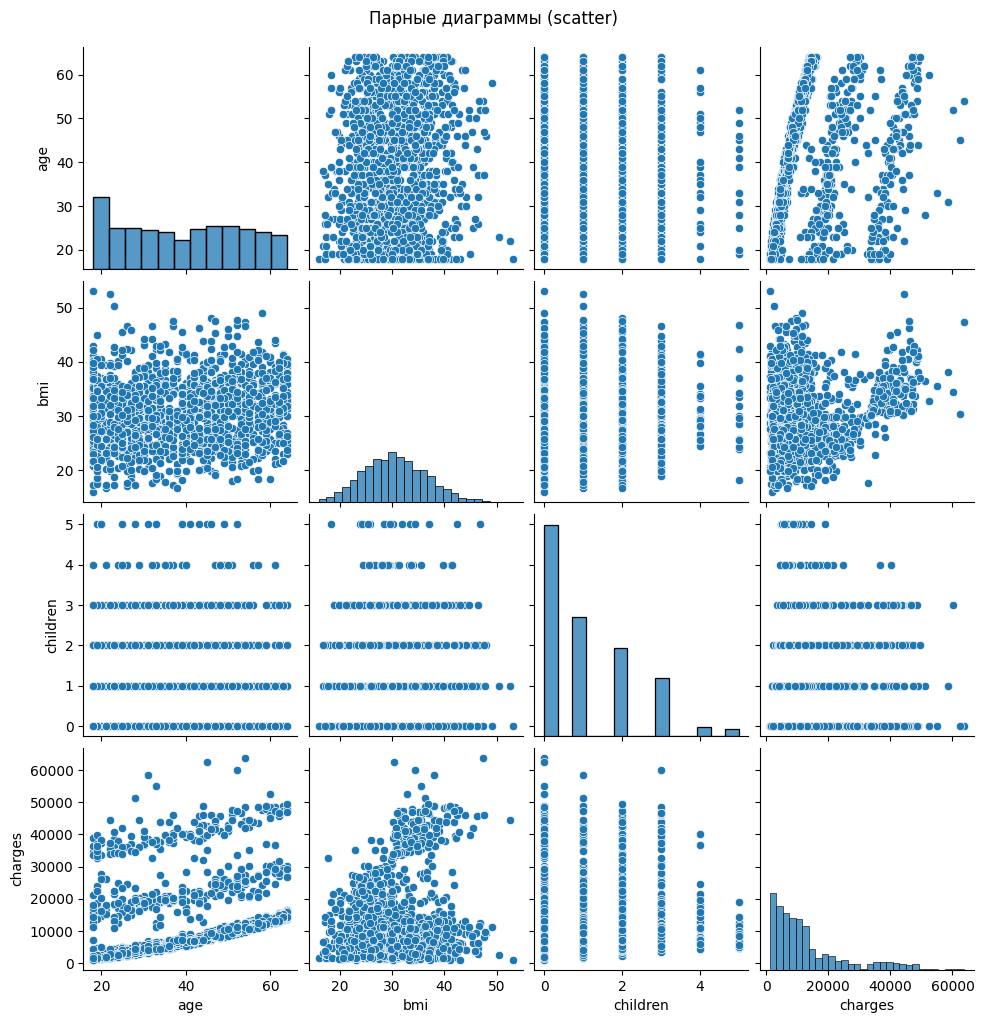

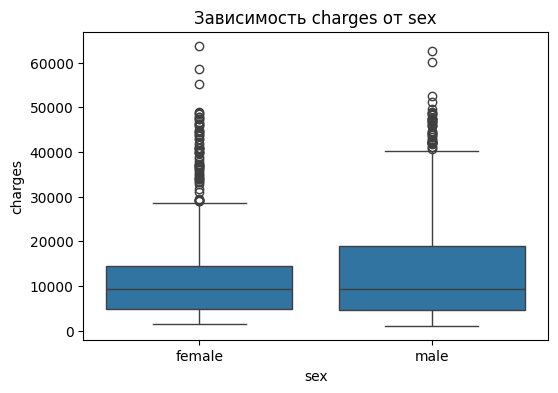

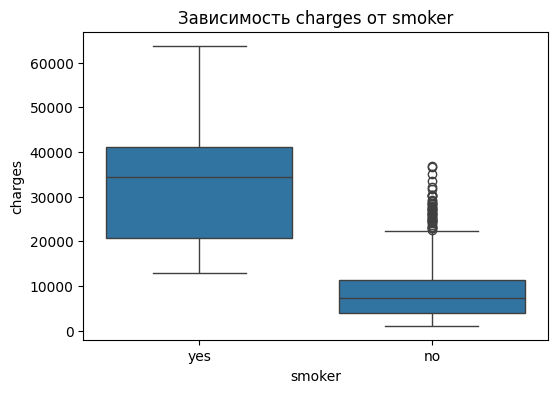

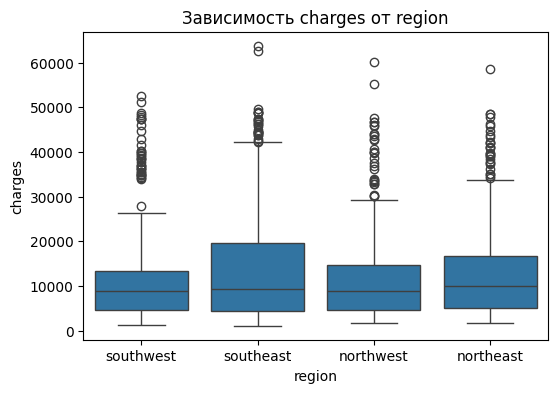

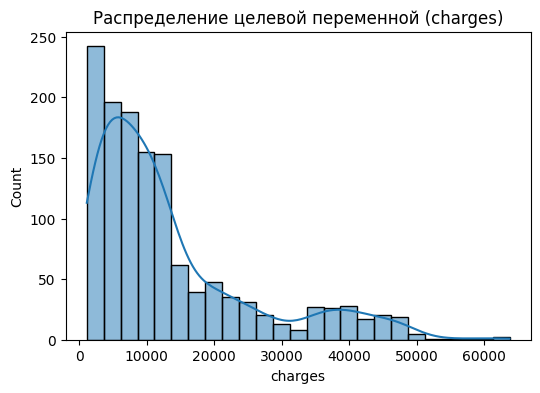

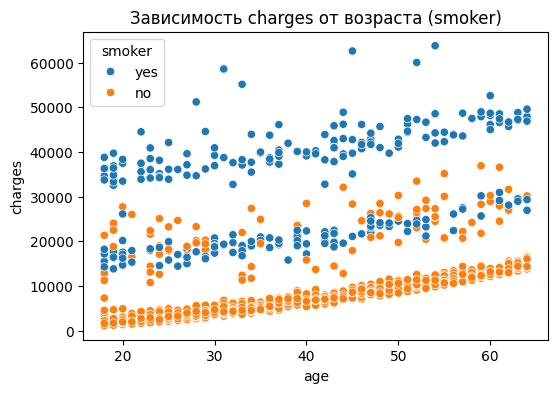

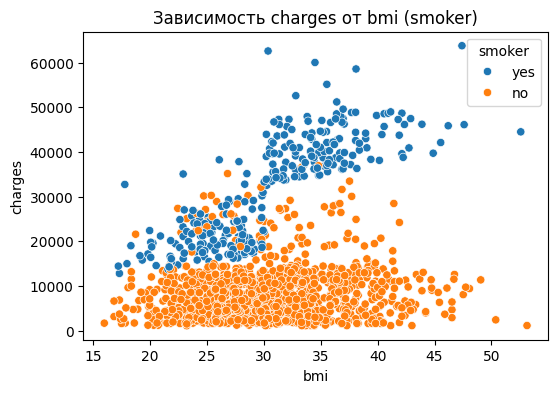

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats

nums = ['age', 'bmi', 'children', 'charges']

for col in nums:
    plt.figure(figsize=(6,4))
    sns.histplot(df[col], kde=True, bins=20)
    plt.title(f'Распределение {col}')
    plt.show()

for col in nums:
    plt.figure(figsize=(4,4))
    stats.probplot(df[col], dist="norm", plot=plt)
    plt.title(f'QQ-Plot для {col}')
    plt.show()

plt.figure(figsize=(6,4))
sns.heatmap(df[nums].corr(), annot=True)
plt.title('Корреляционная матрица')
plt.show()

sns.pairplot(df[nums])
plt.suptitle('Парные диаграммы (scatter)', y=1.02)
plt.show()

kat_cols = ['sex', 'smoker', 'region']
for col in kat_cols:
    plt.figure(figsize=(6,4))
    sns.boxplot(x=col, y='charges', data=df)
    plt.title(f'Зависимость charges от {col}')
    plt.show()

plt.figure(figsize=(6,4))
sns.histplot(df['charges'], kde=True, bins=25)
plt.title('Распределение целевой переменной (charges)')
plt.show()

plt.figure(figsize=(6,4))
sns.scatterplot(x='age', y='charges', hue='smoker', data=df)
plt.title('Зависимость charges от возраста (smoker)')
plt.show()

plt.figure(figsize=(6,4))
sns.scatterplot(x='bmi', y='charges', hue='smoker', data=df)
plt.title('Зависимость charges от bmi (smoker)')
plt.show()

## Задание 4: Статистический анализ

1. Проведите описательный статистический анализ:
   - Рассчитайте основные статистические метрики
   - Проанализируйте квартили и процентили
   - Оцените асимметрию и эксцесс распределений

2. Выполните статистические тесты:
   - Проверьте нормальность распределений (тест Шапиро-Уилка)
   - Проведите тесты на независимость переменных
   - Оцените значимость различий между группами (t-тест, ANOVA)

3. Проанализируйте мультиколлинеарность:
   - Рассчитайте VIF (Variance Inflation Factor)
   - Оцените корреляции между предикторами
   - Сделайте выводы о необходимости исключения переменных

In [5]:
from scipy.stats import shapiro, ttest_ind, f_oneway

numeric_cols = ['age', 'bmi', 'children', 'charges']

print("Описательная статистика по числовым признакам:")
for column in numeric_cols:
    print(f"\n{column}:")
    print(f"Среднее: {df[column].mean():.2f}")
    print(f"Медиана: {df[column].median():.2f}")
    print(f"Стандарт отклонение: {df[column].std():.2f}")
    print(f"Асимметрия: {df[column].skew():.2f}")
    print(f"Эксцесс: {df[column].kurt():.2f}")
    print(f"25-й перцентиль: {df[column].quantile(0.25):.2f}")
    print(f"75-й перцентиль: {df[column].quantile(0.75):.2f}")

print("\nShapiro–Wilk:")
for column in numeric_cols:
    stat, p = shapiro(df[column])
    if p > 0.05:
        result = "норм"
    else:
        result = "не норм"
    print(f"{column}: statistic={stat:.3f}, p={p:.3f} → {result}")

print("\nСравнение средних для курящих и некурящих:")
charges_smokers = df[df['smoker'] == 'yes']['charges']
charges_nonsmokers = df[df['smoker'] == 'no']['charges']
t_stat, p_val = ttest_ind(charges_smokers, charges_nonsmokers)
print(f"T-test: t={t_stat:.3f}, p={p_val:.3f}")

print("\nразличия между регионами:")
region_groups = [df[df['region'] == r]['charges'] for r in df['region'].unique()]
f_stat, p_val = f_oneway(*region_groups)
print(f"ANOVA: F={f_stat:.3f}, p={p_val:.3f}")

Описательная статистика по числовым признакам:

age:
Среднее: 39.21
Медиана: 39.00
Стандарт отклонение: 14.05
Асимметрия: 0.06
Эксцесс: -1.25
25-й перцентиль: 27.00
75-й перцентиль: 51.00

bmi:
Среднее: 30.66
Медиана: 30.40
Стандарт отклонение: 6.10
Асимметрия: 0.28
Эксцесс: -0.05
25-й перцентиль: 26.30
75-й перцентиль: 34.69

children:
Среднее: 1.09
Медиана: 1.00
Стандарт отклонение: 1.21
Асимметрия: 0.94
Эксцесс: 0.20
25-й перцентиль: 0.00
75-й перцентиль: 2.00

charges:
Среднее: 13270.42
Медиана: 9382.03
Стандарт отклонение: 12110.01
Асимметрия: 1.52
Эксцесс: 1.61
25-й перцентиль: 4740.29
75-й перцентиль: 16639.91

Shapiro–Wilk:
age: statistic=0.945, p=0.000 → не норм
bmi: statistic=0.994, p=0.000 → не норм
children: statistic=0.823, p=0.000 → не норм
charges: statistic=0.815, p=0.000 → не норм

Сравнение средних для курящих и некурящих:
T-test: t=46.665, p=0.000

различия между регионами:
ANOVA: F=2.970, p=0.031


## Задание 5: Подготовка признаков

1. Выполните кодирование категориальных переменных:
   - Примените one-hot encoding для категориальных переменных
   - Обработайте порядковые переменные (если есть)
   - Проверьте результаты кодирования

2. Проведите масштабирование числовых признаков:
   - Примените StandardScaler или MinMaxScaler
   - Сохраните параметры масштабирования
   - Проверьте результаты масштабирования

3. Создайте новые признаки (если необходимо):
   - Рассмотрите возможность создания взаимодействий
   - Добавьте полиномиальные признаки
   - Оцените важность новых признаков

In [6]:
from sklearn.preprocessing import OneHotEncoder, StandardScaler
import pandas as pd

data = df.copy()

# One-hot encoding для категориальных переменных
categorical = ['sex', 'smoker', 'region']
encoder = OneHotEncoder(drop='first', sparse_output=False)
encoded = pd.DataFrame(encoder.fit_transform(data[categorical]), columns=encoder.get_feature_names_out(categorical))

# Объединение с остальными данными
data = pd.concat([data.drop(categorical, axis=1), encoded], axis=1)

print("Первые строки после кодирования:")
print(data.head())

# Масштабирование числовых признаков
numeric = ['age', 'bmi', 'children', 'charges']
scaler = StandardScaler()
data[numeric] = scaler.fit_transform(data[numeric])

print("\nПервые строки после масштабирования:")
print(data.head())

#добавление нового признака (взаимодействие)
data['bmi_age'] = data['bmi'] * data['age']

print("\nНовые признаки добавлены:")
print(data[['bmi', 'age', 'bmi_age']].head())


Первые строки после кодирования:
   age     bmi  children      charges  sex_male  smoker_yes  region_northwest  \
0   19  27.900         0  16884.92400       0.0         1.0               0.0   
1   18  33.770         1   1725.55230       1.0         0.0               0.0   
2   28  33.000         3   4449.46200       1.0         0.0               0.0   
3   33  22.705         0  21984.47061       1.0         0.0               1.0   
4   32  28.880         0   3866.85520       1.0         0.0               1.0   

   region_southeast  region_southwest  
0               0.0               1.0  
1               1.0               0.0  
2               1.0               0.0  
3               0.0               0.0  
4               0.0               0.0  

Первые строки после масштабирования:
        age       bmi  children   charges  sex_male  smoker_yes  \
0 -1.438764 -0.453320 -0.908614  0.298584       0.0         1.0   
1 -1.509965  0.509621 -0.078767 -0.953689       1.0         0.0   
2

## Задание 6: Построение модели линейной регрессии

1. Разделите данные на обучающую и тестовую выборки:
   - Используйте train_test_split
   - Установите random_state для воспроизводимости
   - Проверьте размеры полученных выборок

2. Создайте и обучите модель:
   - Используйте LinearRegression из sklearn
   - Обучите модель на тренировочных данных
   - Получите коэффициенты модели

3. Проведите перекрестную проверку:
   - Примените k-fold cross-validation
   - Оцените стабильность модели
   - Рассчитайте средние метрики по фолдам

In [12]:
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LinearRegression
import numpy as np
import pandas as pd

# Кодирование категориальных переменных
df_encoded = pd.get_dummies(df, drop_first=True)

# Разделение данных
X = df_encoded.drop('charges', axis=1)
y = df_encoded['charges']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Размер обучающей выборки:", X_train.shape)
print("Размер тестовой выборки:", X_test.shape)

model = LinearRegression()
model.fit(X_train, y_train)

print("\nКоэффициенты модели:")
for name, coef in zip(X.columns, model.coef_):
    print(f"{name}: {coef:.2f}")
print("Свободный член:", model.intercept_)

# Перекрёстная проверка
scores = cross_val_score(model, X, y, cv=5, scoring='r2')
print("\nR в квадрате по фолдам:", np.round(scores, 3))
print("Среднее значение R в квадрате:", np.mean(scores).round(3))

Размер обучающей выборки: (1070, 8)
Размер тестовой выборки: (268, 8)

Коэффициенты модели:
age: 256.98
bmi: 337.09
children: 425.28
sex_male: -18.59
smoker_yes: 23651.13
region_northwest: -370.68
region_southeast: -657.86
region_southwest: -809.80
Свободный член: -11931.219050326688

R в квадрате по фолдам: [0.761 0.706 0.778 0.733 0.756]
Среднее значение R в квадрате: 0.747


## Задание 7: Оценка модели и диагностика

1. Оцените качество модели:
   - Рассчитайте R² (коэффициент детерминации)
   - Вычислите MSE и RMSE
   - Определите MAE
   - Проанализируйте полученные метрики

2. Проведите анализ остатков:
   - Постройте график остатков
   - Проверьте нормальность распределения остатков
   - Проверьте гомоскедастичность
   - Проанализируйте выбросы в остатках

3. Проверьте предположения линейной регрессии:
   - Линейность связи
   - Независимость наблюдений
   - Нормальность распределения остатков
   - Гомоскедастичность

R^2: 0.784
MSE: 33596915.85
RMSE: 5796.28
MAE: 4181.19


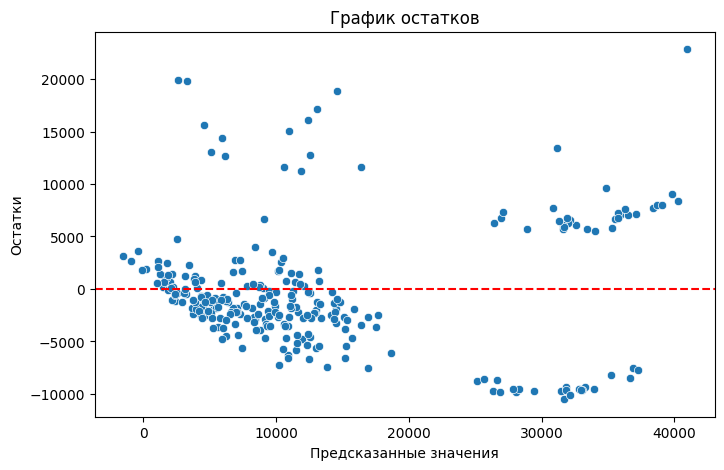

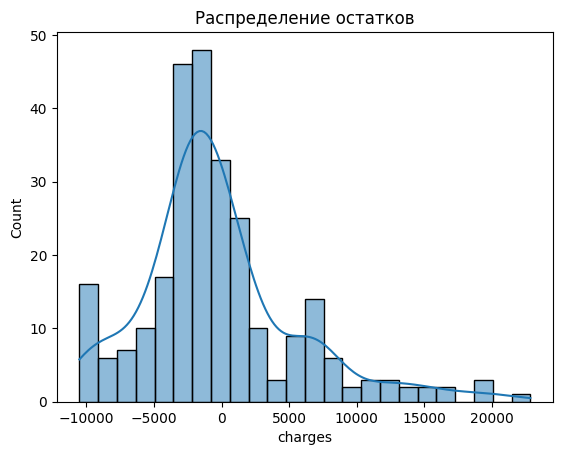

Shapiro-Wilk тест: statistic=0.914, p=0.000
Остатки не распределены нормально


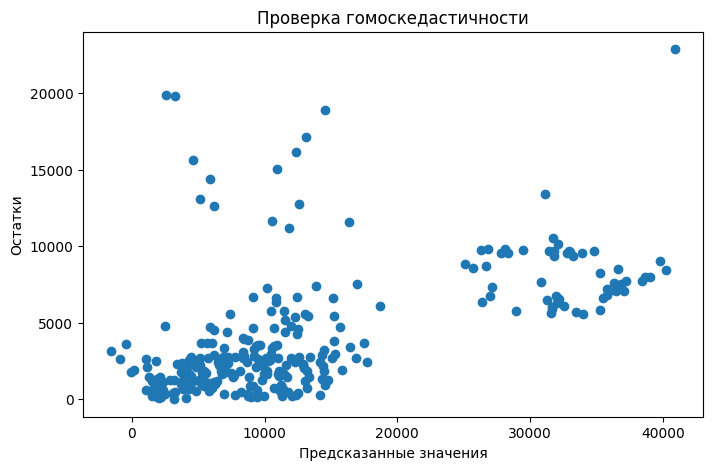

In [8]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from scipy.stats import shapiro

# Предсказания и остатки
y_pred = model.predict(X_test)
residuals = y_test - y_pred

#метрики
r2 = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)

print(f"R^2: {r2:.3f}")
print(f"MSE: {mse:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"MAE: {mae:.2f}")

# остатки
plt.figure(figsize=(8, 5))
sns.scatterplot(x=y_pred, y=residuals)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("Предсказанные значения")
plt.ylabel("Остатки")
plt.title("График остатков")
plt.show()

# нормальности остатков
sns.histplot(residuals, kde=True)
plt.title("Распределение остатков")
plt.show()

stat, p = shapiro(residuals)
print(f"Shapiro-Wilk тест: statistic={stat:.3f}, p={p:.3f}")
if p > 0.05:
    print("Остатки распределены нормально")
else:
    print("Остатки не распределены нормально")

# равномерности остатков
plt.figure(figsize=(8, 5))
plt.scatter(y_pred, abs(residuals))
plt.xlabel("Предсказанные значения")
plt.ylabel("Остатки")
plt.title("Проверка гомоскедастичности")
plt.show()


## Задание 8: Визуализация результатов

1. Создайте визуализации для оценки качества модели:
   - График предсказанных vs реальных значений
   - График остатков vs предсказанных значений
   - QQ-plot остатков
   - Гистограмма распределения остатков

2. Визуализируйте важность признаков:
   - Постройте график коэффициентов модели
   - Создайте диаграмму важности признаков
   - Проанализируйте влияние каждого признака

3. Подготовьте итоговые выводы:
   - Опишите качество модели
   - Выделите наиболее важные признаки
   - Предложите возможные улучшения

## Бонусное задание

1. Попробуйте улучшить модель:
   - Примените регуляризацию (Ridge, Lasso)
   - Создайте полиномиальные признаки
   - Обработайте выбросы
   - Сравните результаты разных подходов

2. Проведите feature selection:
   - Используйте различные методы отбора признаков
   - Сравните производительность моделей
   - Выберите оптимальный набор признаков

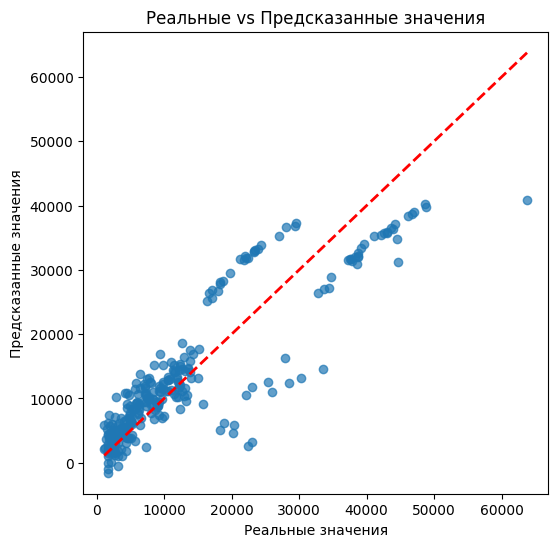

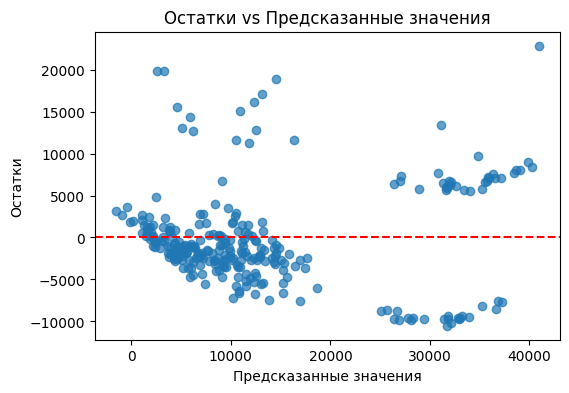

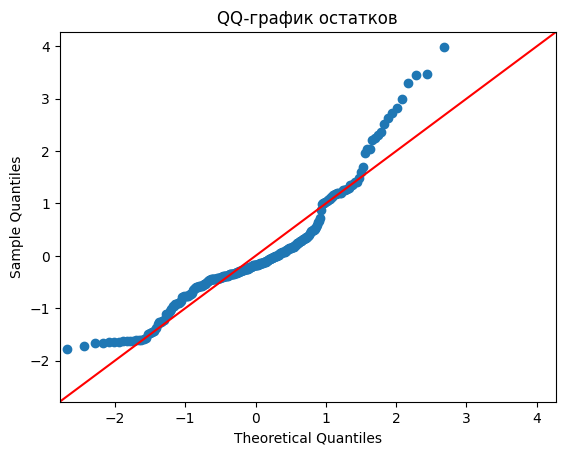

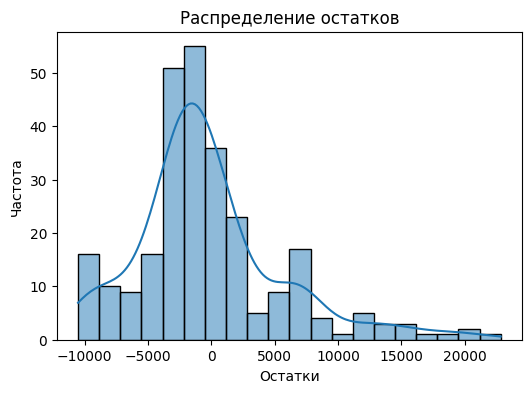

C:\Users\laste\AppData\Local\Temp\ipykernel_16180\2775457236.py:45: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Коэффициент', y='Признак', data=coefficients, palette='viridis')


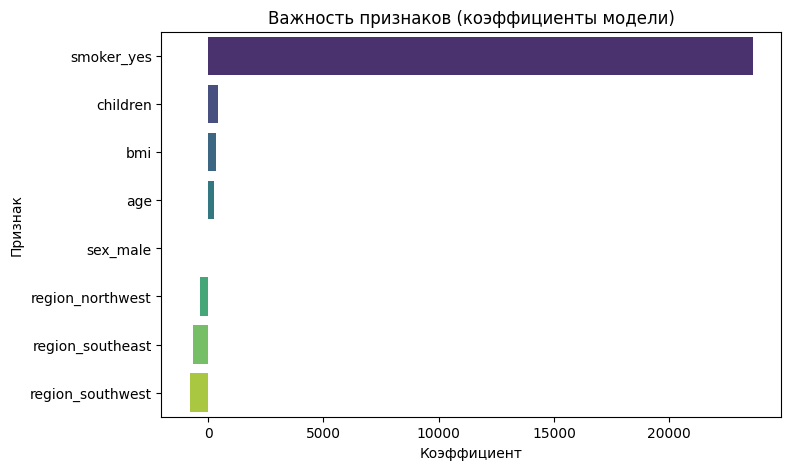

Модель показывает, что хорошо предсказания совпадают с реальными значениями.
На графике коэффициентов видно, какие признаки наиболее влияют на переменную.


In [11]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import statsmodels.api as sm


plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_pred, alpha=0.7)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel("Реальные значения")
plt.ylabel("Предсказанные значения")
plt.title("Реальные vs Предсказанные значения")
plt.show()


residuals = y_test - y_pred
plt.figure(figsize=(6, 4))
plt.scatter(y_pred, residuals, alpha=0.7)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("Предсказанные значения")
plt.ylabel("Остатки")
plt.title("Остатки vs Предсказанные значения")
plt.show()


sm.qqplot(residuals, line='45', fit=True)
plt.title("QQ-график остатков")
plt.show()


plt.figure(figsize=(6, 4))
sns.histplot(residuals, bins=20, kde=True)
plt.title("Распределение остатков")
plt.xlabel("Остатки")
plt.ylabel("Частота")
plt.show()


coefficients = pd.DataFrame({
    'Признак': X.columns,
    'Коэффициент': model.coef_
}).sort_values(by='Коэффициент', ascending=False)

plt.figure(figsize=(8, 5))
sns.barplot(x='Коэффициент', y='Признак', data=coefficients, palette='viridis')
plt.title("Важность признаков (коэффициенты модели)")
plt.show()


print("Модель показывает, что хорошо предсказания совпадают с реальными значениями.")
print("На графике коэффициентов видно, какие признаки наиболее влияют на переменную.")
